## Volatility Pockets of Predictability Replication

In [4]:
using Pkg
Pkg.activate(".")

  Activating project at `c:\Users\mikul\Desktop\Persistence of Shocks\tvPersistence.jl - Cleaned\volatility_results_replication`


In [5]:
using BSON
using Colors
using CSV
using DataFrames
using StatsBase
using Plots

In [13]:
include("../src/SED_Thresholds/SEDThresholds.jl")
using .SEDThresholds

#### Load Data

In [6]:
### NEW with RW bechmark ####
tt=1000
test1 = BSON.load("volatility_forecast_results/results_RV_SP500_final_predictions_$tt-1.bson")
test5 = BSON.load("volatility_forecast_results/results_RV_SP500_final_predictions_$tt-5.bson")
test22 = BSON.load("volatility_forecast_results/results_RV_SP500_final_predictions_$tt-22.bson")

res1=test1["forecasts"];
res5=test5["forecasts"];
res22=test22["forecasts"];

names=["HAR" "EWD" "TV-AR3" "TV-HAR" "TV-EWD"]

RW1 = BSON.load("volatility_forecast_results/results_RV_SP500_RW_predictions_$tt-1.bson")
RW5 = BSON.load("volatility_forecast_results/results_RV_SP500_RW_predictions_$tt-5.bson")
RW22 = BSON.load("volatility_forecast_results/results_RV_SP500_RW_predictions_$tt-22.bson")
RW1=RW1["forecasts"];
RW5=RW5["forecasts"];
RW22=RW22["forecasts"];

res1all = [hcat(res1[i][:, 1], RW1[i][], res1[i][:, 2:end]) for i in 1:496];
res5all = [hcat(res5[i][:, 1], RW5[i][], res5[i][:, 2:end]) for i in 1:496];
res22all = [hcat(res22[i][:, 1], RW22[i][], res22[i][:, 2:end]) for i in 1:496];

# Now, we added the second row - RW
names=["RW" "HAR" "EWD" "TV-AR3" "TV-HAR" "TV-EWD"];

In [7]:
datum = CSV.read("volatility_forecast_results/dates.csv", DataFrame)
datum=Matrix(datum);

tt=1000 
datpos=datum[tt+22+1:end]
sel=[[1; size(res1[1])[1]] [1;751] [1751;2001]]

start = 740; 
start1 = 2500;

datum[[start+71;start+195;start1+71;start1+195]]

4-element Vector{Dates.Date}:
 2008-10-02
 2009-04-03
 2015-10-27
 2016-04-28

In [8]:
lev1=0.05
lev5=0.05
lev22=0.05

yl=0.0001;
yh=0.0004;

k=1;   ### Change of period here ###
t1=sel[1,k]
t2=sel[2,k] 

rv_true1=hcat([Float64.(res1all[j][t1:t2,1]) for j in 1:496]...)
rv_true5=hcat([Float64.(res5all[j][t1:t2-5,1]) for j in 1:496]...)
rv_true22=hcat([Float64.(res22all[j][t1:t2-22,1]) for j in 1:496]...);

err_all1=[hcat([Float64.(winsor(res1all[j][t1:t2,1].-res1all[j][t1:t2,1+jj],prop=lev1)) for j in 1:496]...) for jj=1:6]
err_all5=[hcat([Float64.(winsor(res5all[j][t1:t2-5,1].-res5all[j][t1:t2-5,1+jj],prop=lev1)) for j in 1:496]...) for jj=1:6]
err_all22=[hcat([Float64.(winsor(res22all[j][t1:t2-22,1].-res22all[j][t1:t2-22,1+jj],prop=lev1)) for j in 1:496]...) for jj=1:6];
err_all1[6][isnan.(err_all1[6])].=0.0
err_all5[6][isnan.(err_all5[6])].=0.0
err_all22[6][isnan.(err_all22[6])].=0.0;

In [9]:
bw = 0.01
stock=1;
bootthr=[[0.0003467599642181169 4.011045083750926e-6 1.2019772866130706e-5]
    [3.1122818805228614e-5 1.0934609909422118e-5 2.402437424495225e-6]
    [6.82026230827422e-6 5.688913526381037e-6 4.251738505230786e-6]]

3×3 Matrix{Float64}:
 0.00034676  4.01105e-6  1.20198e-5
 3.11228e-5  1.09346e-5  2.40244e-6
 6.82026e-6  5.68891e-6  4.25174e-6

In [10]:
x_ticks_volatility = ([100,351,602,848,1095,1343,1593,1844,2091],
["2010","2011","2012","2013","2014","2015","2016","2017","2018"])
mycolor=[colorant"rgb(222,102,62)",colorant"rgb(255,145,43)",colorant"rgb(76,144,186)",colorant"rgb(43,194,194)",colorant"rgb(244,184,17)"]

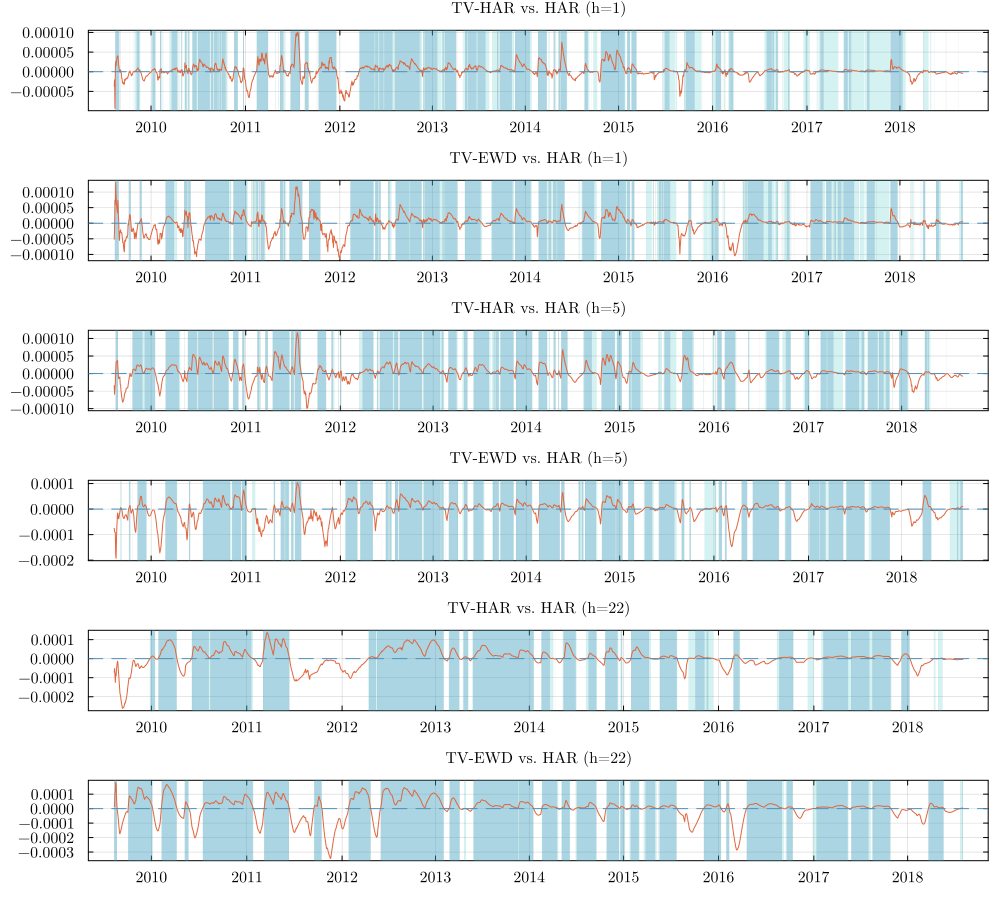

In [14]:
p1 = SEDThresholds.plot_pockets(
    err_all1[2][:,stock],
    err_all1[5][:,stock],
    datum,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-HAR vs. HAR (h=1)",
    auto_xticks = false,
    user_xticks = x_ticks_volatility,
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p2 = SEDThresholds.plot_pockets(
    err_all1[2][:,stock],
    err_all1[6][:,stock],
    datum,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-EWD vs. HAR (h=1)",
    auto_xticks = false,
    user_xticks = x_ticks_volatility,
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p3 = SEDThresholds.plot_pockets(
    err_all5[2][:,stock],
    err_all5[5][:,stock],
    datum,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-HAR vs. HAR (h=5)",
    auto_xticks = false,
    user_xticks = x_ticks_volatility,
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p4 = SEDThresholds.plot_pockets(
    err_all5[2][:,stock],
    err_all5[6][:,stock],
    datum,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-EWD vs. HAR (h=5)",
    auto_xticks = false,
    user_xticks = x_ticks_volatility,
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p5 = SEDThresholds.plot_pockets(
    err_all22[2][:,stock],
    err_all22[5][:,stock],
    datum,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-HAR vs. HAR (h=22)",
    auto_xticks = false,
    user_xticks = x_ticks_volatility,
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p6 = SEDThresholds.plot_pockets(
    err_all22[2][:,stock],
    err_all22[6][:,stock],
    datum,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-EWD vs. HAR (h=22)",
    auto_xticks = false,
    user_xticks = x_ticks_volatility,
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

pockets_plot_vol = plot(p1,p2,p3,p4,p5,p6, layout = (6,1), legend = false, size = (1000, 900))
plot!(pockets_plot_vol, fontfamily="serif-roman",xtickfontsize=10,ytickfontsize=10)

In [15]:
savefig(pockets_plot_vol, "../readme_files/pockets_plot_volatility.pdf")

"c:\\Users\\mikul\\Desktop\\Persistence of Shocks\\tvPersistence.jl - Cleaned\\readme_files\\pockets_plot_volatility.pdf"